In [2]:
import random
from typing import Iterable
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
import torch

from datasets import load_dataset,Dataset, DatasetDict

from transformers import AutoTokenizer,AutoModelForSequenceClassification,DataCollatorWithPadding,Trainer,TrainingArguments

In [3]:
# Фиксируем seed и определяем устройство.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [21]:
dataset = load_dataset("emotion")

C:\Users\fazil\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\fazil\.cache\huggingface\hub\datasets--emotion. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating test split: 100%|████████████████████████████████████████████| 2000/2000 [00:00<00:00, 223142.

In [22]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [23]:
print(dataset["train"].features["label"])

ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])


В датасете Emotion классифицируются короткие тексты (фразы, сообщения, твиты) по 6 типам эмоций:
Sadness (Грусть) — печаль, уныние, разочарование, чувство потери;
Joy (Радость) — счастье, удовольствие, положительные эмоции;
Love (Любовь) — привязанность, симпатия, теплые чувства;
Anger (Гнев) — раздражение, злость, агрессия;
Fear (Страх) — тревога, беспокойство, опасения;
Surprise (Удивление) — неожиданность, изумление, шок.

In [24]:
for i in range(10):
    print(f'Текст: {dataset["train"].shuffle(seed=42)[i]["text"]}')
    print(f'Метка: {dataset["train"].shuffle(seed=42)[i]["label"]}')

Текст: while cycling in the country
Метка: 4
Текст: i had pocket qq and was feeling pretty confident lol
Метка: 1
Текст: i am in no way complaining or whining or feeling ungrateful
Метка: 0
Текст: i feel a bit stressed because it feels like im supposed to do something all the time and that i should be reading now
Метка: 3
Текст: i tell the people closest to me things that i am feeling and its as if they arent surprised because theyd known it all along
Метка: 5
Текст: when my relatives and i were in a car going slowly on a frozen road
Метка: 4
Текст: i am trying to work on finding the joy in the simple thing that god is finding joy in my obedience to him even if it doesn t feel very joyful in the way that i am used to
Метка: 1
Текст: i know intellectually that it s not true but i feel entirely isolated
Метка: 0
Текст: i suppose he feels badly because he was a bit skeptical of her pain over the last few months shes had a hyperchondria and exaggeration habit in the past though he never op

In [25]:
train_data = dataset["train"]    
val_data = dataset["validation"]      
test_data = dataset["test"]  

print(f"Train: {len(train_data)}")      
print(f"Validation: {len(val_data)}")   
print(f"Test: {len(test_data)}")        

Train: 16000
Validation: 2000
Test: 2000


bert-base-uncased стандарт для английской классификации текста,мы же будет использовать- distilbert-base-uncased - облегчённая версия со скоростью в два раза большей.

In [51]:
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded:", tokenizer.__class__.__name__)
print("Model checkpoint:", MODEL_NAME)

def tokenize_batch(batch: Dict[str, List[str]]) -> Dict[str, List[List[int]]]:
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=64,
    )

dataset_dict = DatasetDict({
    "train": train_data,
    "validation": val_data,
    "test": test_data
})
tokenized_datasets = dataset_dict.map(tokenize_batch, batched=True)
# Удаляем столбец "text": DataCollatorWithPadding попытается преобразовать
# все поля датасета в тензоры, а строки в тензор не конвертируются.
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets


Tokenizer loaded: BertTokenizer
Model checkpoint: distilbert-base-uncased


DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

базовый разбор токенизации

In [52]:
for i in range(5):
    example = tokenized_datasets["train"][i]

    print(f"ПРИМЕР {i+1}")
    
    # Токены
    tokens = tokenizer.convert_ids_to_tokens(example["input_ids"])
    print(f"Токены: {tokens}")
    
    # input_ids
    print(f"input_ids: {example['input_ids']}")
    
    # attention_mask
    print(f"attention_mask: {example['attention_mask']}")
    
    # Special tokens
    print(f"Special tokens: [CLS]={example['input_ids'][0]}, [SEP]={example['input_ids'][-1]}")
    
    print(f"Декодированный текст: {tokenizer.decode(example['input_ids'])}")

ПРИМЕР 1
Токены: ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]']
input_ids: [101, 1045, 2134, 2102, 2514, 26608, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1]
Special tokens: [CLS]=101, [SEP]=102
Декодированный текст: [CLS] i didnt feel humiliated [SEP]
ПРИМЕР 2
Токены: ['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake', '[SEP]']
input_ids: [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Special tokens: [CLS]=101, [SEP]=102
Декодированный текст: [CLS] i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake [SEP]
ПРИМЕР 3
Токены: ['[CLS]', 'im', 'grabbing', 'a', 'minute', 'to', 'post', 'i', 'feel', 'greedy', 'wrong', '[SEP

будем использовать динамический padding

In [53]:
# Data collator будет добавлять padding динамически, прямо при формировании батча.
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Показываем длины ДО padding
print("До padding:")
for i in range(5):
    print(f"  Пример {i}: {len(tokenized_datasets['train'][i]['input_ids'])} токенов")

sample_batch = [tokenized_datasets["train"][i] for i in range(5)]
collated_batch = data_collator(sample_batch)

print("\nПосле padding:")
for key, value in collated_batch.items():
    print(f"{key}: shape={tuple(value.shape)}")



До padding:
  Пример 0: 7 токенов
  Пример 1: 23 токенов
  Пример 2: 12 токенов
  Пример 3: 22 токенов
  Пример 4: 8 токенов

После padding:
input_ids: shape=(5, 23)
token_type_ids: shape=(5, 23)
attention_mask: shape=(5, 23)
labels: shape=(5,)


In [54]:
id2label = {0: "sadness", 1: "joy", 2: "love", 3: "anger",4: "fear",5: "surprise"}

label2id = {v: k for k, v in id2label.items()}

# Загружаем модель для классификации.
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=6,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

model.to(device)

print("Model class:", model.__class__.__name__)
print("Number of labels:", model.config.num_labels)
print("id2label:", model.config.id2label)


Loading weights: 100%|█████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 3673.70it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model class: DistilBertForSequenceClassification
Number of labels: 6
id2label: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


In [55]:
# Функция метрик для Trainer.
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    f1_weighted = f1_score(labels, preds, average="weighted")

    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
    }

обучение

In [57]:
# Общие параметры обучения.
common_training_kwargs = dict(
    output_dir="outputs/s13_bert_finetuning_demo",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=2,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
)

try:
    training_args = TrainingArguments(
        evaluation_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )
except TypeError:
    training_args = TrainingArguments(
        eval_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )

# Собираем Trainer и запускаем обучение.
# В transformers >= 5.0 аргумент tokenizer переименован в processing_class.
try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
except TypeError:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

train_result = trainer.train()
train_result

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.046862,0.222004,0.930000,0.902663,0.930571
2,0.198013,0.201411,0.933500,0.908134,0.933168
3,0.000983,0.207948,0.942000,0.916849,0.942037
4,0.067576,0.276454,0.939500,0.915634,0.939834
5,0.000316,0.286088,0.939500,0.914567,0.939484


Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.33s/it]
C:\Users\fazil\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.13s/it]
C:\Users\fazil\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.29s/it]
C:\Users\fazil\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_m

TrainOutput(global_step=10000, training_loss=0.13091349817360315, metrics={'train_runtime': 11853.4267, 'train_samples_per_second': 6.749, 'train_steps_per_second': 0.844, 'total_flos': 852279452677728.0, 'train_loss': 0.13091349817360315, 'epoch': 5.0})

метрики лучшего варинта на validation и test

In [58]:
# В transformers >= 5.x NotebookProgressCallback теряет состояние после обучения,
# что вызывает RuntimeError при вызове evaluate() вне тренировочного цикла.
# Удаляем его перед standalone-оценкой – это стандартный обходной путь.
from transformers.utils.notebook import NotebookProgressCallback
trainer.remove_callback(NotebookProgressCallback)

# Оценка Trainer на validation и test.
val_metrics = trainer.evaluate(tokenized_datasets["validation"])
test_metrics = trainer.evaluate(tokenized_datasets["test"])

print("Validation metrics:")
for k, v in val_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

print("\nTest metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

C:\Users\fazil\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\fazil\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Validation metrics:
eval_loss: 0.2080
eval_accuracy: 0.9420
eval_f1_macro: 0.9168
eval_f1_weighted: 0.9420
eval_runtime: 68.1332
eval_samples_per_second: 29.3540
eval_steps_per_second: 3.6690
epoch: 5.0000

Test metrics:
eval_loss: 0.2550
eval_accuracy: 0.9235
eval_f1_macro: 0.8787
eval_f1_weighted: 0.9238
eval_runtime: 67.5081
eval_samples_per_second: 29.6260
eval_steps_per_second: 3.7030
epoch: 5.0000


C:\Users\fazil\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


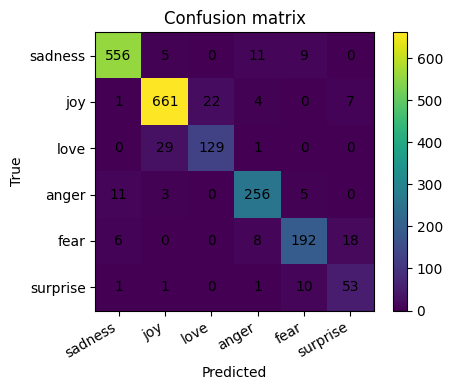

In [62]:
# матрица ошибок
test_output = trainer.predict(tokenized_datasets["test"])
test_logits = test_output.predictions
test_preds = np.argmax(test_logits, axis=-1)
test_true = test_output.label_ids
label_names = dataset["train"].features["label"].names

cm = confusion_matrix(test_true, test_preds)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)

ax.set_xticks(range(len(label_names)))
ax.set_yticks(range(len(label_names)))
ax.set_xticklabels(label_names, rotation=30, ha="right")
ax.set_yticklabels(label_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("artifacts/confusion_matrix.png", dpi=100,bbox_inches='tight')
plt.show()

In [65]:
# Вспомогательная функция для инференса 
def predict_texts(texts: List[str], true_labels: List[int] = None) -> pd.DataFrame:
    encoded = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128,
    )
    encoded = {k: v.to(device) for k, v in encoded.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**encoded)
        probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()

    pred_ids = probs.argmax(axis=1)

    rows = []
    for i, (text, pred_id, prob_vector) in enumerate(zip(texts, pred_ids, probs)):
        row = {
            "text": text,
            "pred_label": id2label[int(pred_id)],
            "confidence": float(prob_vector[pred_id]),
        }
        for class_id, class_name in id2label.items():
            row[f"prob_{class_name}"] = float(prob_vector[class_id])
        
        if true_labels is not None:
            row["true_label"] = id2label[true_labels[i]]
        
        rows.append(row)

    return pd.DataFrame(rows)

инференс готовой pretrained модели на нескольких текстах;

In [78]:
# случайные 5 индексов
indices = random.sample(range(len(dataset["test"])), 10)

# Для тестовых данных
test_texts = [dataset["test"]["text"][i] for i in indices]
test_labels = [dataset["test"]["label"][i] for i in indices]

df = predict_texts(test_texts, true_labels=test_labels)
df.to_csv("artifacts/predictions.csv", index=False, encoding="utf-8")
df

,text,pred_label,confidence,prob_sadness,prob_joy,prob_love,prob_anger,prob_fear,prob_surprise,true_label
0,im feeling exponentially more useless on the f...,sadness,0.999908,0.999908,0.000025,0.000004,0.000029,0.000028,0.000006,sadness
1,i don t know how else to describe it except to...,joy,0.748908,0.001583,0.748908,0.249233,0.000129,0.000072,0.000075,joy
2,i feel ecstatic and privileged,joy,0.999877,0.000014,0.999877,0.000080,0.000005,0.000006,0.000019,joy
3,i am on so many social networks right now and ...,joy,0.999531,0.000085,0.999531,0.000154,0.000183,0.000022,0.000025,joy
4,i left there feeling brow beaten,sadness,0.999898,0.999898,0.000016,0.000004,0.000055,0.000023,0.000005,sadness
5,i feel less frightened and more grounded and c...,fear,0.999803,0.000031,0.000021,0.000013,0.000047,0.999803,0.000085,fear
6,i am feeling apprehensive about it but also wi...,fear,0.999810,0.000026,0.000022,0.000015,0.000080,0.999810,0.000048,fear
7,i was feeling weird the other day and it went ...,surprise,0.591813,0.000507,0.000522,0.000518,0.000481,0.406158,0.591813,fear
8,im just feeling emo and bitchy atm,anger,0.995039,0.000296,0.002997,0.000860,0.995039,0.000117,0.000691,anger
9,i feel his hand on me to stay faithful,joy,0.813228,0.000122,0.813228,0.186513,0.000048,0.000035,0.000055,love


In [80]:
# Таблица ошибок на тестовой выборке.
test_texts = test_data["text"]  

error_rows = []

for text, true_id, pred_id, prob_vector in zip(
    test_texts,
    test_true,
    test_preds,
    torch.softmax(torch.tensor(test_logits), dim=-1).numpy()
):
    if true_id != pred_id:
        error_rows.append({
            "text": text,
            "true_label": id2label[int(true_id)],
            "pred_label": id2label[int(pred_id)],
            "pred_confidence": float(prob_vector[pred_id]),
        })

errors_df = pd.DataFrame(error_rows)

if len(errors_df) == 0:
    print("На тестовой выборке ошибок не найдено. Это возможно на маленьком учебном датасете.")
else:
    display(errors_df.sort_values(by="pred_confidence", ascending=False).reset_index(drop=True))

,text,true_label,pred_label,pred_confidence
0,whenever i put myself in others shoes and try ...,anger,joy,0.999876
1,i feel inside cause life is like a game someti...,fear,sadness,0.999869
2,i feel affirmed gracious sensuous and will hav...,love,joy,0.999511
3,i feel unprotected a class post count link hre...,sadness,fear,0.999257
4,i walked to school he felt the bounce in his s...,love,joy,0.999218
...,...,...,...,...
148,i took for granted a few weeks ago is really w...,anger,fear,0.541175
149,i ever recognized what it was to feel passiona...,love,joy,0.531753
150,i feel betrayed and angry and sad at the same ...,anger,sadness,0.529463
151,i feel stressed but i love the feeling of the ...,sadness,anger,0.516533


Модель часто путает близкие по смыслу эмоции (joy–love, sadness–fear, anger–sadness), потому что тексты короткие и содержат смешанные или слабовыраженные сигналы, а высокая уверенность в ошибках показывает, что она переобучилась на поверхностные лексические маркеры (например, “feer”, “love”, “sad”) и не улавливает контекст, иронию или комбинации эмоций, поэтому при неоднозначных формулировках выбирает наиболее “похожий” класс даже неправильно